In [3]:
import numpy as np
import xarray as xr
import os
# plottng
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Bbox
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

import palettable.colorbrewer as cb 


import scipy
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy.stats import t as t_dist

from statsmodels.tsa.stattools import ccf
from amocatlas import read

from process_data import MHT_selection, MHT_lat_selection, plot_hovmöller, plot_crosscorr, lowpass_filter

from statistics_func import acf_calc_plot, integral_time_scale, standard_error

In [4]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 16,
    'axes.labelsize'  : 14,
    # ticks
    'xtick.labelsize' : 12,
    'ytick.labelsize' : 12,
    # legend
    'legend.fontsize' : 11,
    'legend.title_fontsize': 12,
    # colorbar
    'figure.titlesize': 18,
})

In [5]:
ds = read.calafat2025()

lats = ds.LATITUDE.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'N' if lat > 0 else 'S'}" for lat in lats][1:]


MHT_dict = MHT_selection(ds, statistics=True, anomalies=True, time_mean=True, drop65=True)

lats = MHT_dict["lats"]
mht = MHT_dict["MHT"] 
mht_stats = MHT_dict["MHT_statistics"] 
mht_mean = mht_stats["mean"] # this is mean over posterior samples!
mht_time_mean = mht_stats["time_mean"]
mht_all_mean = mht_time_mean.mean(dim="posterior_samples")

mht_std = mht_stats["std"]
mht_ci = mht_stats["ci"]

# mht_anom = MHT_dict["MHT_anom"]
# choose one lat: 
lat_sel = 5
MHT_lat = MHT_lat_selection(MHT_dict, lat=lat_sel, ci=90, anomalies=True)

mht_lat = MHT_lat["MHT_lat"]
mht_lat_stats = MHT_lat["MHT_lat_statistics"] 
mht_lat_mean = MHT_lat["MHT_lat_statistics"]["mean"]
mht_lat_time_mean = MHT_lat["MHT_lat_statistics"]["time_mean"]


seasonal_clim = mht_mean.groupby('TIME.month').mean(dim='TIME')  # shape: (12, lat)
seasonal_clim_prob = mht.groupby('TIME.month').mean(dim='TIME')  # shape: (12, lat, posterior_samples)
# subtract it from each timestep
mht_anom = mht_mean.groupby('TIME.month') - seasonal_clim
mht_anom_prob = mht.groupby('TIME.month') - seasonal_clim_prob

mht_deseasonalized = mht_anom + mht_all_mean
mht_deseasonalized_prob = mht_anom_prob + mht_all_mean

mht_smooth = lowpass_filter(mht_deseasonalized)
mht_smooth_prob = lowpass_filter(mht_deseasonalized_prob)

Loading 1 Calafat et al. 2025 dataset(s):
  0. Bayesian_estimates_Atlantic_MHT.zip: No description available



In [6]:
ds = mht_smooth

# for NAN checking

In [7]:

# da = mht_smooth
# print(da.isnull().sum())
# print(f"NaN percentage: {da.isnull().mean() * 100:.2f}%")

# nan_any  = da.isnull().any(dim='TIME')   # True if ANY sample is NaN
# nan_all  = da.isnull().all(dim='TIME')   # True if ALL samples are NaN

# print("Inconsistent NaNs (some samples missing, not all):", 
#       bool((nan_any & ~nan_all).any()))
# # Visualize gaps

# nan_map = da.isnull()

# nan_map.plot(x='TIME', y='lat', cmap='viridis')
# # plt.xlim(right=pd.Timestamp("2005-01-01"))
# plt.title("NaN fraction across posterior samples")


In [8]:
mht_smooth_prob_lat = mht_smooth_prob.mean(dim='lat')
mht_smooth_prob_lat = mht_smooth_prob_lat.mean(dim='posterior_samples')


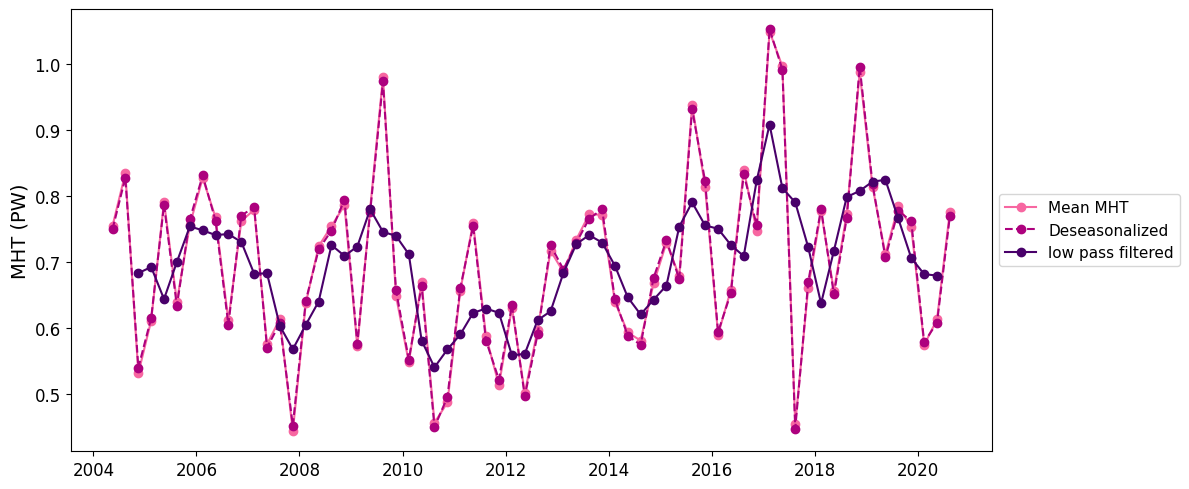

In [9]:
mht_mean_lat = mht_mean.mean(dim="lat")
mht_deseasonalized_lat = mht_deseasonalized.mean(dim="lat")
mht_smooth_lat = mht_smooth.mean(dim="lat")


cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.sequential.RdPu_9.mpl_colors
)

colors = cmap(np.linspace(0.5, 1, 3))

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(mht_mean_lat.TIME, mht_mean_lat, label="Mean MHT", color=colors[0], marker='o', linestyle='-', alpha=1)
ax.plot(mht_deseasonalized_lat.TIME, mht_deseasonalized_lat, label="Deseasonalized", color=colors[1], marker='o', linestyle='--', alpha=1)
ax.plot(mht_smooth_lat.TIME, mht_smooth_lat, label="low pass filtered", color=colors[-1],  marker='o', linestyle='-', alpha=1)
# ax.set_title("MHT timeseries at 5 latitudes")
ax.set_ylabel("MHT (PW)")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig("figures/timeseries/MHT_timeseries.png", dpi=300, bbox_inches='tight')
plt.tight_layout()


In [10]:
ds = mht_smooth

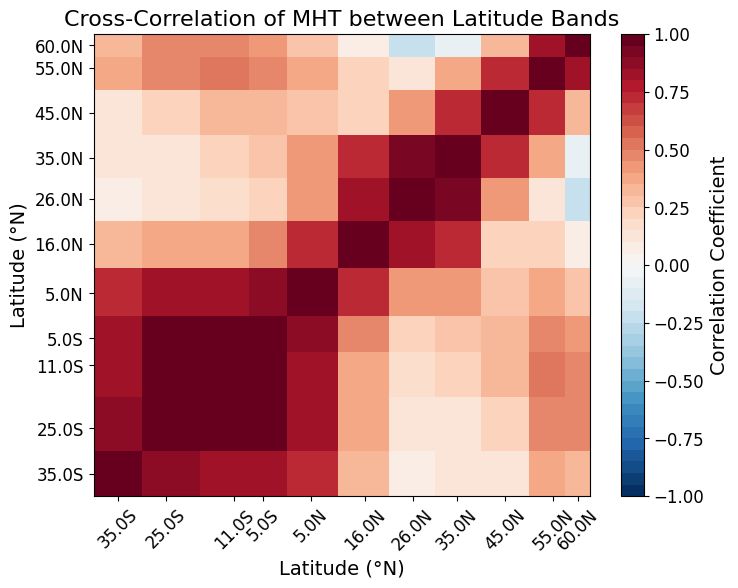

In [11]:

# cmap = plt.cm.RdBu_r
# cmap = cmo.cm.curl

# cmap = mcolors.ListedColormap(cb.diverging.BrBG_20.mpl_colors)
# colors = cmap(np.linspace(0, 1, 20))
# sliced_cmap = mcolors.ListedColormap(colors)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.diverging.RdBu_11_r.mpl_colors
)

colors = cmap(np.linspace(0, 1, 40))
sliced_cmap_corr = mcolors.ListedColormap(colors)


plot_crosscorr(ds, lats, lat_labels, cmap=sliced_cmap_corr, savefig=True)

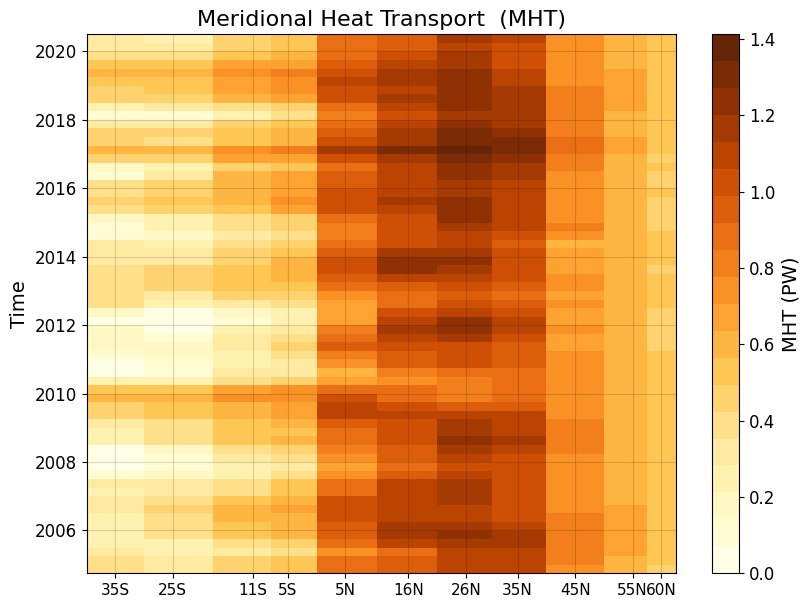

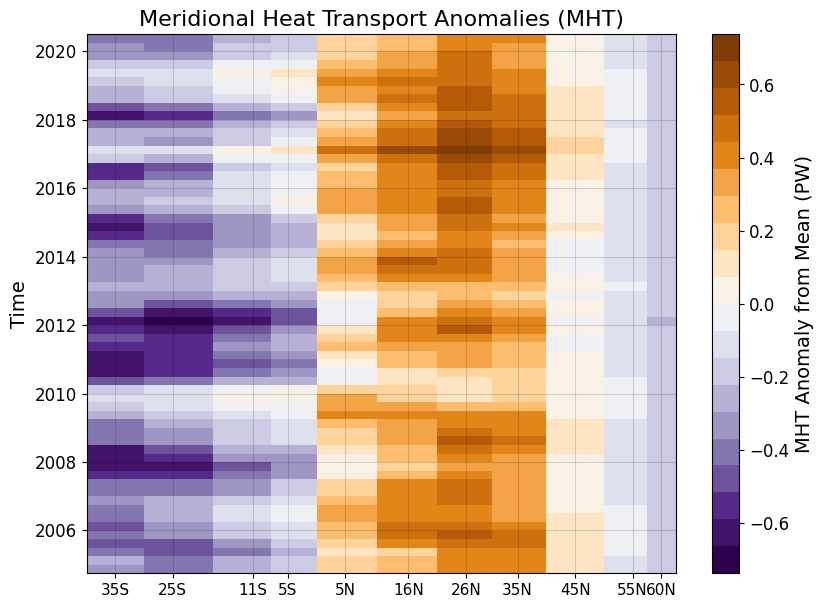

In [12]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.sequential.YlOrBr_9.mpl_colors
)

colors = cmap(np.linspace(0, 1, 20))
sliced_cmap_mht = mcolors.ListedColormap(colors)


plot_hovmöller(ds, lats, cmap=sliced_cmap_mht, savefig=True, anomalies=False)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'BrBG_continuous', cb.diverging.PuOr_11_r.mpl_colors
)

colors = cmap(np.linspace(0, 1, 20))
sliced_cmap_anom = mcolors.ListedColormap(colors)


plot_hovmöller(ds, lats, cmap=sliced_cmap_anom, savefig=True, anomalies=True)

In [13]:
# array([ 60.,  55.,  45.,  35.,  26.,  16.,   5.,  -5., -11., -25., -35.])
ref_lat = 35                   
nlags = 12                        

lats = MHT_dict["lats"]



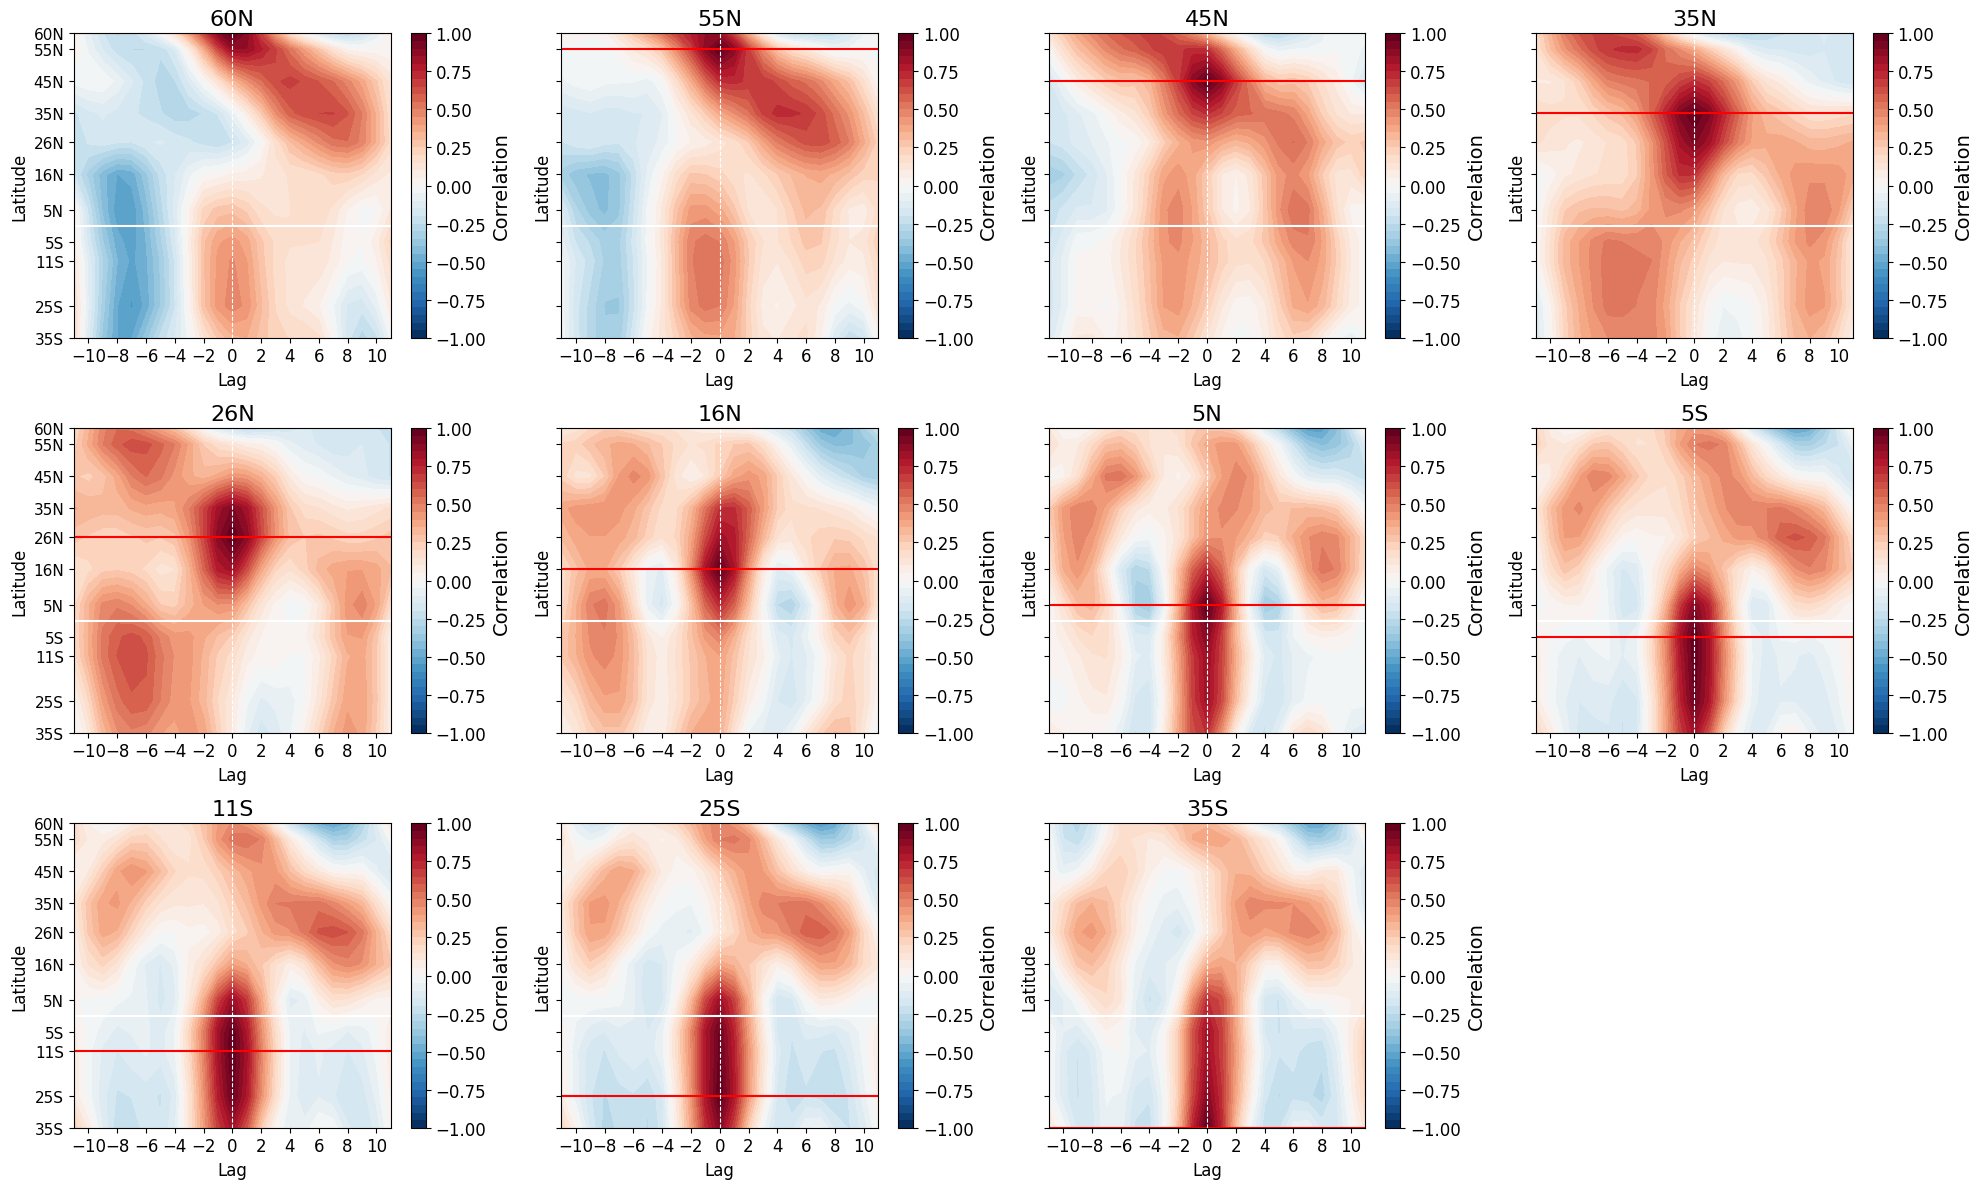

In [14]:

cmap = sliced_cmap_corr
# cmap = cmo.cm.curl
all_lags = np.arange(-(nlags-1), nlags)

corr_matrix = np.full((len(lats), len(all_lags)), np.nan)

ref_lats = lats

ytick_pos    = [-35, -25, -11, -5,  5,  16, 26, 35, 45, 55, 60]
ytick_labels = ["35S","25S","11S","5S","5N","16N","26N","35N","45N","55N","60N"]
   
   
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
axes = axes.flatten() 

MHT_mean = ds

for ax, ref_lat in zip(axes, ref_lats):
    ref_idx = np.argmin(np.abs(lats - ref_lat))
    ts_ref  = MHT_mean.isel(lat=ref_idx).values

    corr_matrix = np.full((len(lats), len(all_lags)), np.nan)
    for i, lat in enumerate(lats):
        ts = MHT_mean.isel(lat=i).values
        pos_corr, _ = ccf(ts_ref, ts,   nlags=nlags, alpha=0.05)
        neg_corr, _ = ccf(ts,   ts_ref, nlags=nlags, alpha=0.05)
        full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
        corr_matrix[i, :] = full_corr

    # --- Plot ---
    cf = ax.contourf(
        all_lags, lats, corr_matrix,
        levels=np.linspace(-1, 1, 41),
        cmap=cmap,
    )
    plt.colorbar(cf, ax=ax, label='Correlation')

    ax.axhline(ref_lat, color='red', linewidth=1.5, label=f'Ref: {ref_lat}°N')
    ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
    ax.axhline(0, color='white', linewidth=1.5)

    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_labels, fontsize=11)
    ax.set_xticks(np.arange(all_lags[1], all_lags[-1] + 1, 2))

    ref_label = f"{abs(ref_lat):.0f}{'N' if ref_lat >= 0 else 'S'}"
    ax.set_xlabel(f'Lag', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'{ref_label}')
    
axes[-1].set_visible(False)
plt.tight_layout()
os.makedirs("figures/lead_lag", exist_ok=True)
plt.savefig(f'figures/lead_lag/lag_corr_ref{ref_lat}N.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# corr_matrix = np.full((len(lats), len(all_lags)), np.nan)


# fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
# axes = axes.flatten() 
# for ax, ref_lat in zip(axes, ref_lats):
#     ref_idx = np.argmin(np.abs(lats - ref_lat))
#     ts_ref  = MHT_mean.isel(lat=ref_idx).values

#     corr_matrix = np.full((len(lats), len(all_lags)), np.nan)
#     for i, lat in enumerate(lats):
#         ts = MHT_mean.isel(lat=i).values
#         pos_corr, _ = ccf(ts_ref, ts,   nlags=nlags, alpha=0.05)
#         neg_corr, _ = ccf(ts,   ts_ref, nlags=nlags, alpha=0.05)
#         full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
#         corr_matrix[i, :] = full_corr


#     peak_lags = np.argmax(corr_matrix, axis=1)           # index of max correlation
#     peak_lags = all_lags[peak_lags]                       # convert to actual lag values
#     peak_corr = np.max(corr_matrix, axis=1)               # correlation at peak lag

#     # plot propagation speed
#     ax.plot(peak_lags, lats, marker="o")
    
#     ax.axhline(ref_lat, color='red', linewidth=1.5, label=f'Ref: {ref_lat}°N')
  
#     ax.set_yticks(ytick_pos)
#     ax.set_yticklabels(ytick_labels, fontsize=11)
#     ax.set_xticks(np.arange(all_lags[1], all_lags[-1] + 1, 2))

    

## statisics - significance testing!

In [16]:
N = len(mht_smooth.isel(lat=0).values)
N

63

In [19]:
def critical_r(n_eff, alpha=0.05):
    df = n_eff - 2
    t_crit = t_dist.ppf(1 - alpha/2, df=df)
    r_crit = t_crit / np.sqrt(t_crit**2 + df)
    return r_crit


In [ ]:
time_unit = "years"  # or "months"
if time_unit == "months":
    del_t = 3
if time_unit == "years":
    del_t = 0.25
    
r_crits = {}

plateau_lats = [45, 35, 26]  # Example latitudes to analyze
for idx, lat in enumerate(lats): 
    mht_lat = mht_smooth.isel(lat=idx)
    # mht_lat_std = mht_lat.std(dim='posterior_samples')
    if lat in plateau_lats:
         method = "plateau"
    else: 
        method = "0cross"
    
    its, max_lags = integral_time_scale(mht_lat, del_t=del_t, method=method)
    
    N_eff = N*del_t/its
    
    
    print(f"Latitude: {lat:.1f}°, ITS: {its:.2f} {time_unit}, N_eff: {N_eff:.1f} samples")
    # _ = acf_calc_plot(mht_lat, N_eff=12, plot=False, title=f"Autocorrelation Function at {lat:.1f}°N")

    r_crits[lat] = critical_r(N_eff)
    print(f"{lat_labels[idx]}: N_eff={N_eff:.1f}, r_crit={r_crits[lat]:.3f}")
    # _ = acf_calc_plot(mht_lat, N_eff=12, plot=False, title=f"Autocorrelation Function at {lat:.1f}°N")
    
    # SE, ITS, N_eff, DOF = standard_error(mht_smooth_prob.values, total_time=,del_t=3, time_unit="months")

Latitude: 60.0°, ITS: 1.36 years, N_eff: 11.6 samples
60.0N: N_eff=11.6, r_crit=0.586
Latitude: 55.0°, ITS: 2.36 years, N_eff: 6.7 samples
55.0N: N_eff=6.7, r_crit=0.771
Latitude: 45.0°, ITS: 0.99 years, N_eff: 15.9 samples
45.0N: N_eff=15.9, r_crit=0.499
Latitude: 35.0°, ITS: 1.43 years, N_eff: 11.0 samples
35.0N: N_eff=11.0, r_crit=0.602
Latitude: 26.0°, ITS: 0.98 years, N_eff: 16.1 samples
26.0N: N_eff=16.1, r_crit=0.496
Latitude: 16.0°, ITS: 0.90 years, N_eff: 17.5 samples
16.0N: N_eff=17.5, r_crit=0.475
Latitude: 5.0°, ITS: 0.50 years, N_eff: 31.2 samples
5.0N: N_eff=31.2, r_crit=0.354
Latitude: -5.0°, ITS: 0.91 years, N_eff: 17.3 samples
5.0S: N_eff=17.3, r_crit=0.478
Latitude: -11.0°, ITS: 0.92 years, N_eff: 17.2 samples
11.0S: N_eff=17.2, r_crit=0.480
Latitude: -25.0°, ITS: 0.89 years, N_eff: 17.7 samples
25.0S: N_eff=17.7, r_crit=0.473
Latitude: -35.0°, ITS: 0.49 years, N_eff: 32.1 samples
35.0S: N_eff=32.1, r_crit=0.349


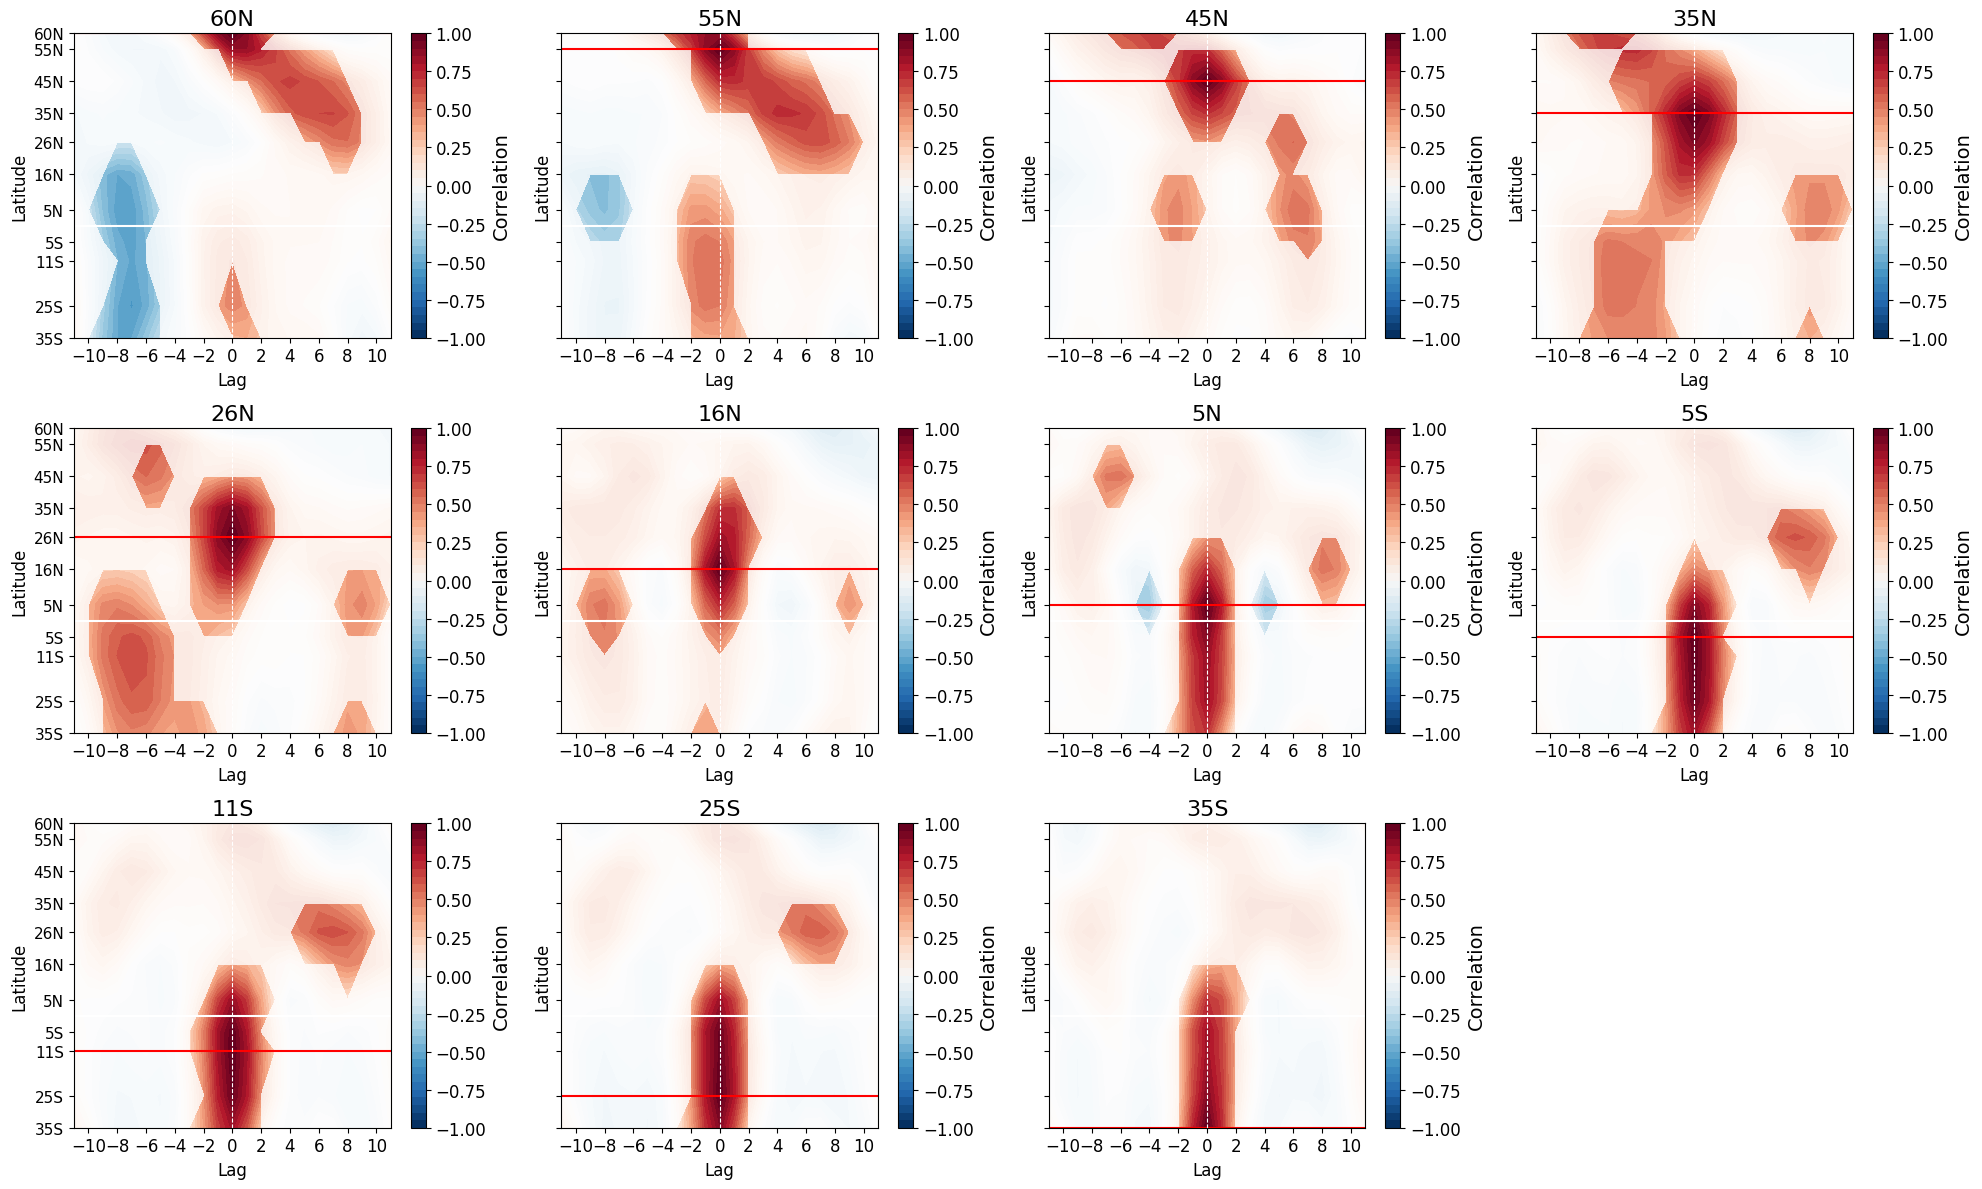

In [ ]:

# cmap = sliced_cmap_corr
# # cmap = cmo.cm.curl
# all_lags = np.arange(-(nlags-1), nlags)

# corr_matrix = np.full((len(lats), len(all_lags)), np.nan)

# ref_lats = lats

# ytick_pos    = [-35, -25, -11, -5,  5,  16, 26, 35, 45, 55, 60]
# ytick_labels = ["35S","25S","11S","5S","5N","16N","26N","35N","45N","55N","60N"]
   
   
# fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)
# axes = axes.flatten() 

# MHT_mean = ds

# for ax, ref_lat in zip(axes, ref_lats):
#     ref_idx = np.argmin(np.abs(lats - ref_lat))
#     ts_ref  = MHT_mean.isel(lat=ref_idx).values

#     corr_matrix = np.full((len(lats), len(all_lags)), np.nan)
#     for i, lat in enumerate(lats):
#         ts = MHT_mean.isel(lat=i).values
#         pos_corr, _ = ccf(ts_ref, ts,   nlags=nlags, alpha=0.05)
#         neg_corr, _ = ccf(ts,   ts_ref, nlags=nlags, alpha=0.05)
#         full_corr = np.concatenate([neg_corr[1:][::-1], pos_corr])
#         corr_matrix[i, :] = full_corr

#     sig_mask = significance_mask(corr_matrix, lats, r_crits)

#     # --- Plot ---
#     cf = ax.contourf(
#         all_lags, lats, corr_matrix,
#         levels=np.linspace(-1, 1, 41),
#         cmap=cmap,
#     )
    

#     plt.colorbar(cf, ax=ax, label='Correlation')

#     ax.axhline(ref_lat, color='red', linewidth=1.5, label=f'Ref: {ref_lat}°N')
#     ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
#     ax.axhline(0, color='white', linewidth=1.5)

#     ax.set_yticks(ytick_pos)
#     ax.set_yticklabels(ytick_labels, fontsize=11)
#     ax.set_xticks(np.arange(all_lags[1], all_lags[-1] + 1, 2))

#     ref_label = f"{abs(ref_lat):.0f}{'N' if ref_lat >= 0 else 'S'}"
#     ax.set_xlabel(f'Lag', fontsize=12)
#     ax.set_ylabel('Latitude', fontsize=12)
#     ax.set_title(f'{ref_label}')
    
# axes[-1].set_visible(False)
# plt.tight_layout()
# os.makedirs("figures/lead_lag", exist_ok=True)
# plt.savefig(f'figures/lead_lag/lag_corr_ref{ref_lat}N.png', dpi=300, bbox_inches='tight')
# plt.show()